# NLP Cuối Kỳ — QA Hệ thống quy chế TDTU
### 4 Cấu hình: A (LLM gốc) | B (LLM+RAG) | C (Fine-tuned) | D (Fine-tuned+RAG)

## 1. Cài thư viện

In [1]:
!pip install -q pymupdf pymupdf4llm underthesea google-generativeai
!pip install -q transformers accelerate bitsandbytes sentencepiece
!pip install -q rouge-score bert-score sacrebleu
!pip install -q faiss-cpu sentence-transformers langchain-text-splitters
!pip install -q peft trl datasets

## 2. Import & Cấu hình các tham số

In [16]:
import torch, random, numpy as np, os, json, re, time, unicodedata, pandas as pd
import matplotlib.pyplot as plt
import pymupdf4llm, fitz
from tqdm.notebook import tqdm
from google.colab import files
import glob
import itertools
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import cohen_kappa_score
from IPython.display import display

import faiss
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import sacrebleu

In [3]:
SEED           = 42
MODEL_NAME     = "Qwen/Qwen2.5-3B-Instruct"
ADAPTER_PATH   = "./checkpoints/lora_adapter"
MAX_NEW_TOKENS = 256
TEMPERATURE    = 0.1
TOP_P          = 0.9
DO_SAMPLE      = False
MAX_SEQ_LENGTH = 512

SYSTEM_PROMPT = (
  "Bạn là trợ lý hỏi đáp về quy chế Trường Đại học Tôn Đức Thắng (TDTU)."
  "- Trả lời chính xác, ngắn gọn, bằng tiếng Việt."
  "- Nếu không chắc chắn hoặc không có thông tin, hãy trả lời: 'Không biết' hoặc 'Không có thông tin'"
  "- Không được bịa hoặc suy đoán thông tin."
)

SYSTEM_PROMPT_RAG = (
  "Bạn là trợ lý hỏi đáp về quy chế Trường Đại học Tôn Đức Thắng (TDTU)."
  "NHIỆM VỤ:"
  "- Chỉ được trả lời dựa trên các đoạn TÀI LIỆU được cung cấp."
  "- Không được sử dụng kiến thức bên ngoài."
  "- Bắt buộc: không phép được suy đoán hoặc tự bổ sung thông tin."
  "- Nếu tài liệu không chứa câu trả lời, phải trả lời: Không tìm thấy thông tin trong tài liệu."
  "- Trả lời ngắn gọn, chính xác, bằng tiếng Việt."
  "- Phải trích dẫn nguồn dữ liệu dưới dạng: Thông tin này được trích dẫn từ [Đoạn x]."
)

# BitsAndBytes config
BNB_CONFIG = BitsAndBytesConfig(
  load_in_4bit              = True,
  bnb_4bit_quant_type       = "nf4",
  bnb_4bit_compute_dtype    = torch.float16,
  bnb_4bit_use_double_quant = True,
)

# Seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Thư mục
for d in ['/content/data/pdfs', '/content/data/texts', '/content/checkpoints', './data', './results']:
  os.makedirs(d, exist_ok=True)

print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
  print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PyTorch: 2.10.0+cu128 | CUDA: True
GPU: Tesla T4 | VRAM: 15.6 GB


## 3. Trích xuất & làm sạch PDF

In [4]:
def normalize_vietnamese(text):
  text = re.sub(r'\s+([\u0300-\u036f\u1dc0-\u1dff])', r'\1', text)
  return unicodedata.normalize('NFC', text)

def flatten_pipe_tables(text):
  lines, out, i = text.split('\n'), [], 0
  while i < len(lines):
    line = lines[i]
    if not line.strip().startswith('|'):
      out.append(line); i += 1; continue
    tbl_lines = []
    while i < len(lines) and lines[i].strip().startswith('|'):
      tbl_lines.append(lines[i]); i += 1
    tbl_lines = [l for l in tbl_lines if not re.match(r'^\|[\-| :]+\|$', l.strip())]
    rows = []
    for l in tbl_lines:
      cells = [re.sub(r'\s+', ' ', c).strip() for c in l.strip().strip('|').split('|')]
      cells = [c for c in cells if c]
      if cells: rows.append(cells)
    if not rows: continue
    headers, data_start = (rows[0], 1) if rows and not re.match(r'^\d', rows[0][0]) else (None, 0)
    merged, j, data = [], 0, rows[data_start:]
    while j < len(data):
      row = list(data[j])
      while j+1 < len(data) and data[j+1] and data[j+1][0] == row[0]:
        for k in range(1, min(len(row), len(data[j+1]))):
          v = data[j+1][k]
          if v and v not in row[k]: row[k] = (row[k]+' '+v).strip()
        j += 1
      merged.append(row); j += 1
    seen = set()
    for row in merged:
      key = tuple(row[:2])
      if key in seen: continue
      seen.add(key)
      parts = []
      for ci, cell in enumerate(row):
        if not cell: continue
        if headers and ci < len(headers):
          col = headers[ci]
          parts.append(cell if re.match(r'^Col\d+$', col) or not col else f'{col}: {cell}')
        else: parts.append(cell)
      if parts: out.append(' | '.join(parts))
    out.append('')
  return '\n'.join(out)

def merge_wrapped_lines(text):
  lines, merged, i = text.split('\n'), [], 0
  while i < len(lines):
    cur = lines[i].rstrip()
    nxt = lines[i+1].strip() if i+1 < len(lines) else ''
    is_special = bool(re.match(r'^([A-ZĐÀÁẠẢÃÂẦẤẬẨẪĂẰẮẶẲẴ]{3,}|[IVX]+\.|Điều \d|Chương |[-•+]|\d{1,2}\.|$)', cur.strip()))
    ends_ok = bool(re.search(r'[.;:,…\|\)\]]$', cur))
    nxt_ok  = bool(re.match(r'^([IVX]+\.|Điều \d|Chương |[-•+]|\d{1,2}\.|$)', nxt))
    if cur.strip() and not is_special and not ends_ok and len(cur.strip()) < 75 and nxt and not nxt_ok:
      merged.append(cur + ' ' + nxt); i += 2; continue
    merged.append(cur); i += 1
  return '\n'.join(merged)

def merge_split_tables(text):
  pattern = r'(\|\s*\n)\s*(--- Trang \d+ ---\n)\s*(\|[^\n]+\|\s*\n)\s*(\|[\-\|\s]+\|\s*\n)'
  merged = re.sub(pattern, r'\1', text)
  while re.search(pattern, merged): merged = re.sub(pattern, r'\1', merged)
  return merged

def fix_glued_word(text):
  text = re.sub(r'([a-zA-Zà-ỹ])(\d)', r'\1 \2', text)
  text = re.sub(r'(\d)([a-zA-Zà-ỹ])', r'\1 \2', text)
  text = re.sub(r',([a-zA-Zà-ỹ])', r', \1', text)
  dict_replace = {
    "thầycô": "thầy cô", "nhẹnhàng": "nhẹ nhàng", "lịchsự": "lịch sự",
    "đánhgiá": "đánh giá", "Giấykhen": "Giấy khen", "cấpTrường": "cấp Trường",
    "cấpKhoa": "cấp Khoa", "phongtrào": "phong trào", "xãhội": "xã hội",
    "cộngđồng": "cộng đồng", "trungbình": "trung bình", "viphạm": "vi phạm",
    "tácgiảphụ": "tác giả phụ", "chươngtrình": "chương trình",
  }
  for k, v in dict_replace.items(): text = text.replace(k, v)
  return text

def clean_markdown(md):
  md = normalize_vietnamese(md)
  md = re.sub(r'^#{1,6}\s*\*?\*?(.+?)\*?\*?\s*$', r'\1', md, flags=re.MULTILINE)
  md = re.sub(r'\*\*(.+?)\*\*', r'\1', md, flags=re.DOTALL)
  md = re.sub(r'\*\*|_(.+?)_|_', lambda m: m.group(1) if m.group(1) else '', md)
  md = re.sub(r'<br\s*/?>', ' ', md)
  md = merge_split_tables(md)
  md = flatten_pipe_tables(md)
  md = merge_wrapped_lines(md)
  md = fix_glued_word(md)
  md = re.sub(r'[ \t]{2,}', ' ', md)
  md = re.sub(r'\n{3,}', '\n\n', md)
  return md.strip()

def clean_text(text):
  text = re.sub(r'\n{3,}', '\n\n', text)
  text = re.sub(r'[ \t]{2,}', ' ', text)
  text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
  text = re.sub(r'[\uf000-\uf0ff]', '-', text)
  return text.strip()

def extract_text_from_pdf(pdf_path):
  raw = pymupdf4llm.to_markdown(pdf_path, show_progress=False)
  return clean_markdown(raw)

In [20]:
print("Upload các file PDF quy chế TDTU:")
uploaded = files.upload()

all_texts = []
for filename in uploaded.keys():
  if not filename.endswith('.pdf'): continue
  dst = f'/content/data/pdfs/{filename}'
  os.rename(filename, dst)
  print(f"Đang xử lý: {filename}")
  cleaned = clean_text(extract_text_from_pdf(dst))
  txt_path = f'/content/data/texts/{filename.replace(".pdf", ".txt")}'
  with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(cleaned)
  all_texts.append({'source': filename, 'text': cleaned})
  noise = cleaned.count('**') + cleaned.count('<br>')
  print(f"{len(cleaned):,} ký tự | noise còn lại: {noise}")

combined_text = "\n\n".join([f"=== {t['source']} ===\n{t['text']}" for t in all_texts])
with open('./data/combined_corpus.txt', 'w', encoding='utf-8') as f: f.write(combined_text)
print(f"\nTổng cộng: {len(all_texts)} file | {len(combined_text):,} ký tự")

Upload các file PDF quy chế TDTU:


Saving (TV)-Hướng dẫn giao tiếp, ứng xử cho người học.pdf to (TV)-Hướng dẫn giao tiếp, ứng xử cho người học.pdf
Saving 17.Thong tin phong ban.pdf to 17.Thong tin phong ban.pdf
Saving Bộ Quy tắc ứng xử của người học.pdf to Bộ Quy tắc ứng xử của người học.pdf
Saving Điều kiện về việc cấp thư khen học tập - rèn luyện cho sinh viên.pdf to Điều kiện về việc cấp thư khen học tập - rèn luyện cho sinh viên.pdf
Saving Hướng dẫn học bổng, khen thưởng, hỗ trợ người học; học bổng hỗ trợ cho cộng đồng và hỗ trợ khác năm học 2025 - 2026.pdf to Hướng dẫn học bổng, khen thưởng, hỗ trợ người học; học bổng hỗ trợ cho cộng đồng và hỗ trợ khác năm học 2025 - 2026.pdf
Saving MÔ TẢ 5 ĐẶC ĐIỂM NHẬN DIỆN SINH VIÊN TDTU.pdf to MÔ TẢ 5 ĐẶC ĐIỂM NHẬN DIỆN SINH VIÊN TDTU.pdf
Saving Nhiệm vụ thực hiện 3 nội dung đạo đức.pdf to Nhiệm vụ thực hiện 3 nội dung đạo đức.pdf
Saving PHỤ LỤC NHỮNG ĐIỀU SINH VIÊN KHÔNG ĐƯỢC LÀM; NỘI DUNG VI PHẠM VÀ HÌNH THỨC XỬ LÝ SINH VIÊN.pdf to PHỤ LỤC NHỮNG ĐIỀU SINH VIÊN KHÔNG ĐƯỢC LÀM

## 4. Chia dữ liệu Train/Val/Test

In [5]:
with open('./data/qa.json', encoding='utf-8') as f:
  raw = f.read()
data = json.loads(re.sub(r',\s*\n\s*\n\s*\]', '\n]', raw))

random.seed(SEED)
random.shuffle(data)
n = len(data)
train = data[:int(n*0.8)]
val = data[int(n*0.8):int(n*0.9)]
test = data[int(n*0.9):]

for split, name in [(train,'train'), (val,'val'), (test,'test')]:
  with open(f'./data/{name}.json', 'w', encoding='utf-8') as f:
    json.dump(split, f, ensure_ascii=False, indent=2)

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')

Train: 404 | Val: 51 | Test: 51


## 5. Hàm tiện ích: Prompt, Sinh câu trả lời, Đánh giá mô hình

In [6]:
# Hàm tạo promt
def build_prompt(question, contexts = None):
  if contexts is None:
    return [
      {"role": "system", "content": SYSTEM_PROMPT},
      {"role": "user", "content": question},
    ]
  context_text = "\n\n".join([f"[Đoạn {i+1}]: {c}" for i, c in enumerate(contexts)])
  return [
    {"role": "system", "content": SYSTEM_PROMPT_RAG},
    {"role": "user", "content": f"Tài liệu:\n{context_text}\n\nCâu hỏi: {question}"},
  ]


# tạo hàm sinh câu trả lời
STOP_TOKENS = ["<|im_end|>", "<|im_start|>", "\n\n\n"]

def make_generate_fn(llm_model, llm_tokenizer, rag_pipeline=None, max_input_len=512):
  @torch.inference_mode()
  def _generate(question):
    contexts = rag_pipeline.retrieve(question) if rag_pipeline else None
    messages = build_prompt(question, contexts)
    text = llm_tokenizer.apply_chat_template(
      messages, tokenize=False, add_generation_prompt=True
    )
    inputs = llm_tokenizer(
      text, return_tensors="pt", truncation=True,
      max_length=2048 if rag_pipeline else max_input_len,
    ).to(llm_model.device)
    with torch.amp.autocast("cuda"):
      output_ids = llm_model.generate(
        **inputs,
        max_new_tokens = MAX_NEW_TOKENS,
        temperature = TEMPERATURE,
        top_p = TOP_P,
        do_sample = DO_SAMPLE,
        repetition_penalty= 1.15,
        eos_token_id = llm_tokenizer.eos_token_id,
        pad_token_id = llm_tokenizer.pad_token_id,
      )
    generated_ids = output_ids[0][inputs['input_ids'].shape[1]:]
    answer = llm_tokenizer.decode(generated_ids, skip_special_tokens=True)
    for stop in STOP_TOKENS:
      if stop in answer: answer = answer[:answer.index(stop)]
    return answer.strip()
  return _generate


# hàm đánh giá tính BLEU/ROUGE/BERTScore/Recall@K.
def evaluate(config_name, model_name, generate_fn, test_data, rag_pipeline=None):
  records = []
  for item in tqdm(test_data, desc=f"[Config {config_name}] Inference"):
    t0   = time.time()
    pred = generate_fn(item["question"])
    records.append({
      "id"        : item.get("id", ""),
      "question"  : item["question"],
      "reference" : item["answer"],
      "prediction": pred,
      "source"    : item.get("source", ""),
      "config"    : config_name,
      "latency_s" : round(time.time() - t0, 2),
    })
  predictions = [r["prediction"] for r in records]
  references  = [r["reference"]  for r in records]
  bleu = sacrebleu.corpus_bleu(predictions, [references]).score
  scorer_r = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=False)
  r1, r2, rL = [], [], []
  for pred, ref in zip(predictions, references):
    s = scorer_r.score(ref, pred)
    r1.append(s["rouge1"].fmeasure)
    r2.append(s["rouge2"].fmeasure)
    rL.append(s["rougeL"].fmeasure)
  print(f"[Config {config_name}] Tính BERTScore...")
  _, _, F1 = bert_score(
    predictions, references,
    lang="vi", model_type="vinai/phobert-base-v2",
    num_layers=12, verbose=False, device="cuda",
  )
  recall_k = None
  if rag_pipeline is not None:
    recall_k = rag_pipeline.recall_at_k(test_data)
  k_label = f"Recall@{rag_pipeline.top_k}" if rag_pipeline else "Recall@K"
  metrics = {
    "config": config_name,
    "model": model_name,
    "n_test": len(test_data),
    "BLEU": round(bleu, 4),
    "ROUGE-1": round(np.mean(r1), 4),
    "ROUGE-2": round(np.mean(r2), 4),
    "ROUGE-L": round(np.mean(rL), 4),
    "BERTScore-F1": round(F1.mean().item(), 4),
    k_label: round(recall_k, 4) if recall_k is not None else "N/A",
    "latency_avg": round(np.mean([r["latency_s"] for r in records]), 2),
  }
  print(f"\nKẾT QUẢ CONFIG {config_name}\n")
  for k, v in metrics.items(): print(f"  {k:<20}: {v}")
  return metrics, records


def save_results(config_name, metrics, records):
  os.makedirs("./results", exist_ok=True)
  with open(f"./results/metrics_{config_name}.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
  with open(f"./results/predictions_{config_name}.json", "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2)
  print(f"[Config {config_name}] Đã lưu kết quả → ./results/")

## 6. RAG Pipeline (dùng chung cho Config B và D)

In [7]:
class RAGPipeline:
  def __init__(self, corpus_path="./data/combined_corpus.txt",
               embed_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
               chunk_size=500, chunk_overlap=100,
               top_k=5,
               index_path="./checkpoints/faiss_rag.index",
               chunks_path="./checkpoints/rag_chunks.npy"):
    self.corpus_path = corpus_path
    self.embed_model = embed_model
    self.chunk_size = chunk_size
    self.chunk_overlap = chunk_overlap
    self.top_k = top_k
    self.index_path = index_path
    self.chunks_path = chunks_path
    self.chunks = []
    self.index = None
    self.embedder = None

  def load_and_chunk(self):
    with open(self.corpus_path, encoding="utf-8") as f:
      raw = f.read()
    splitter = RecursiveCharacterTextSplitter(
      chunk_size=self.chunk_size, chunk_overlap=self.chunk_overlap,
      separators=["\n\n","\n","."," ",""], length_function=len,
    )
    return [c.strip() for c in splitter.split_text(raw) if len(c.strip()) > 50]

  def build_index(self, force_rebuild=False):
    os.makedirs(os.path.dirname(self.index_path), exist_ok=True)
    print(f"[RAG] Load embedding model: {self.embed_model}")
    self.embedder = SentenceTransformer(self.embed_model)
    if not force_rebuild and os.path.exists(self.index_path) and os.path.exists(self.chunks_path):
      print("[RAG] Load từ cache...")
      self.index  = faiss.read_index(self.index_path)
      self.chunks = np.load(self.chunks_path, allow_pickle=True).tolist()
      print(f"[RAG] {len(self.chunks)} chunks, dim={self.index.d}")
      return
    print("[RAG] Chunking corpus...")
    self.chunks = self.load_and_chunk()
    print(f"[RAG] {len(self.chunks)} chunks | avg {np.mean([len(c) for c in self.chunks]):.0f} ký tự")
    print("[RAG] Encoding chunks...")
    embeddings = self.embedder.encode(
      self.chunks, batch_size=64, show_progress_bar=True,
      convert_to_numpy=True, normalize_embeddings=True,
    ).astype("float32")
    dim = embeddings.shape[1]
    self.index = faiss.IndexFlatIP(dim)
    self.index.add(embeddings)
    faiss.write_index(self.index, self.index_path)
    np.save(self.chunks_path, np.array(self.chunks, dtype=object))
    print(f"[RAG] Index built & saved: {self.index.ntotal} vectors")

  def retrieve(self, query, top_k=None):
    if self.index is None:
      raise RuntimeError("Chưa build index.")
    k = top_k or self.top_k
    q_emb = self.embedder.encode([query], normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    _, indices = self.index.search(q_emb, k)
    return [self.chunks[i] for i in indices[0] if i < len(self.chunks)]

  def recall_at_k(self, test_data, top_k=None):
    k = top_k or self.top_k
    hits = sum(
      1 for item in test_data
      if item.get("context", "").strip() and
        any(item["context"][:80] in r for r in self.retrieve(item["question"], top_k=k))
    )
    return hits / len(test_data) if test_data else 0.0


# Build RAG
rag = RAGPipeline(corpus_path="./data/combined_corpus.txt")
rag.build_index()

[RAG] Load embedding model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[RAG] Load từ cache...
[RAG] 593 chunks, dim=384


## 7. Load model & Tokenizer

In [8]:
print(f"Load tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token
  tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Load model 4-bit: {MODEL_NAME}")
model = AutoModelForCausalLM.from_pretrained(
  MODEL_NAME, quantization_config=BNB_CONFIG, device_map="auto", trust_remote_code=True
)
model.eval()

if torch.cuda.is_available():
  print(f"VRAM sau load: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("Model gốc đã load")

Load tokenizer: Qwen/Qwen2.5-3B-Instruct
Load model 4-bit: Qwen/Qwen2.5-3B-Instruct


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

VRAM sau load: 2.54 GB
Model gốc đã load


## 8. Config A — LLM gốc (không RAG)

In [9]:
generate_A = make_generate_fn(model, tokenizer)

# Test thử 1 câu
print(f"Q: {test[0]['question']}")
print(f"Pred: {generate_A(test[0]['question'])}")
print(f"Gold: {test[0]['answer']}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q: Sinh viên mồ côi cả cha lẫn mẹ có được ưu tiên gì khi đánh giá điểm rèn luyện không?
Pred: Tôi không biết điều này theo quy chế hiện tại của trường. Bạn nên liên hệ với Ban Đào tạo để có câu trả lời chính xác nhất.
Gold: Có, sinh viên thuộc đối tượng mồ côi cả cha lẫn mẹ sẽ được Nhà trường ưu tiên, động viên và cộng điểm khuyến khích khi đánh giá rèn luyện. Khoa hoặc Phân hiệu sẽ xem xét nỗ lực của sinh viên để đề xuất mức điểm cộng phù hợp trình Ban Giám hiệu phê duyệt.


In [ ]:
metrics_A, records_A = evaluate("A", MODEL_NAME, generate_A, test)
save_results("A", metrics_A, records_A)

[Config A] Inference:   0%|          | 0/51 [00:00<?, ?it/s]

[Config A] Tính BERTScore...


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



KẾT QUẢ CONFIG A

  config              : A
  model               : Qwen/Qwen2.5-3B-Instruct
  n_test              : 51
  BLEU                : 5.7249
  ROUGE-1             : 0.5651
  ROUGE-2             : 0.218
  ROUGE-L             : 0.3085
  BERTScore-F1        : 0.5536
  Recall@K            : N/A
  latency_avg         : 6.62
[Config A] Đã lưu kết quả → ./results/


## 9. Config B — LLM gốc + RAG

In [10]:
generate_B = make_generate_fn(model, tokenizer, rag_pipeline=rag)

print(f"Q: {test[0]['question']}")
print(f"Pred: {generate_B(test[0]['question'])}")
print(f"Gold: {test[0]['answer']}")

Q: Sinh viên mồ côi cả cha lẫn mẹ có được ưu tiên gì khi đánh giá điểm rèn luyện không?
Pred: Sinh viên mồ côi cả cha lẫn mẹ sẽ được ưu tiên, động viên, khuyến khích, cộng điểm khi đánh giá kết quả rèn luyện. Điều này dựa trên thông tin từ Đoạn 1 của tài liệu. 

Thông tin này được trích dẫn từ: "Trường hợp là người khuyết tật, tàn tật, mồ côi cả cha lẫn mẹ hoặc cha hoặc mẹ, hoàn cảnh gia đình đặc biệt khó khăn có xác nhận của địa phương theo quy định đối với những hoạt động rèn luyện không có khả năng tham gia hoặc đáp ứng yêu cầu chung".
Gold: Có, sinh viên thuộc đối tượng mồ côi cả cha lẫn mẹ sẽ được Nhà trường ưu tiên, động viên và cộng điểm khuyến khích khi đánh giá rèn luyện. Khoa hoặc Phân hiệu sẽ xem xét nỗ lực của sinh viên để đề xuất mức điểm cộng phù hợp trình Ban Giám hiệu phê duyệt.


In [ ]:
metrics_B, records_B = evaluate("B", MODEL_NAME, generate_B, test, rag_pipeline=rag)
save_results("B", metrics_B, records_B)

[Config B] Inference:   0%|          | 0/51 [00:00<?, ?it/s]/tmp/ipykernel_752/2299279993.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[Config B] Inference: 100%|██████████| 51/51 [10:04<00:00, 11.85s/it]


[Config B] Tính BERTScore...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



KẾT QUẢ CONFIG B
  config              : B
  model               : Qwen/Qwen2.5-3B-Instruct
  n_test              : 51
  BLEU                : 11.4346
  ROUGE-1             : 0.6739
  ROUGE-2             : 0.3153
  ROUGE-L             : 0.3883
  BERTScore-F1        : 0.6419
  Recall@5            : 0.098
  latency_avg         : 11.85
[Config B] Đã lưu kết quả → ./results/


## 10. Fine-tune — QLoRA

In [11]:
with open('./data/train.json', encoding='utf-8') as f:
  train_data = json.load(f)
with open('./data/val.json', encoding='utf-8') as f:
  val_data = json.load(f)
print(f"Train: {len(train_data)} | Val: {len(val_data)}")

def format_sample(item):
  messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": item["question"]},
    {"role": "assistant", "content": item["answer"]},
  ]
  return {"text": tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)}

train_dataset = Dataset.from_list([format_sample(x) for x in train_data])
val_dataset   = Dataset.from_list([format_sample(x) for x in val_data])
print(f"Train dataset: {len(train_dataset)} | Val dataset: {len(val_dataset)}")
print("\nVí dụ sample:")
print(train_dataset[0]['text'][:300], "...")

Train: 404 | Val: 51
Train dataset: 404 | Val dataset: 51

Ví dụ sample:
<|im_start|>system
Bạn là trợ lý hỏi đáp về quy chế Trường Đại học Tôn Đức Thắng (TDTU).- Trả lời chính xác, ngắn gọn, bằng tiếng Việt.- Nếu không chắc chắn hoặc không có thông tin, hãy trả lời: 'Không biết' hoặc 'Không có thông tin'- Không được bịa hoặc suy đoán thông tin.<|im_end|>
<|im_start|>use ...


In [ ]:
from huggingface_hub import login
login(token="")

In [ ]:
# Load lại model để fine-tune
model_for_ft = AutoModelForCausalLM.from_pretrained(
  MODEL_NAME, quantization_config=BNB_CONFIG, device_map="auto", trust_remote_code=True
)
model_for_ft = prepare_model_for_kbit_training(model_for_ft)

lora_config = LoraConfig(
  task_type = TaskType.CAUSAL_LM,
  r = 16, lora_alpha=32, lora_dropout=0.05, bias="none",
  target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
)
model_for_ft = get_peft_model(model_for_ft, lora_config)

trainable = sum(p.numel() for p in model_for_ft.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_for_ft.parameters())
print(f"Trainable: {trainable:,} ({100*trainable/total:.2f}%) / Total: {total:,}")

sft_config = SFTConfig(
  output_dir="./checkpoints/sft_output",
  num_train_epochs=10,
  per_device_train_batch_size=2,
  per_device_eval_batch_size=2,
  gradient_accumulation_steps=8,
  learning_rate=2e-4,
  lr_scheduler_type="cosine",
  warmup_steps=6,
  weight_decay=0.01,
  optim="paged_adamw_8bit",
  logging_steps=10,
  eval_strategy="epoch",
  save_strategy="epoch",
  load_best_model_at_end=True,
  metric_for_best_model="eval_loss",
  gradient_checkpointing=True,
  gradient_checkpointing_kwargs={"use_reentrant": False},
  report_to="none",
  seed=SEED,
  push_to_hub = True,
  hub_model_id = "lpv30/NLP-CK",
  hub_strategy = "every_save",   # push mỗi khi save checkpoint
)

trainer = SFTTrainer(
  model=model_for_ft, args=sft_config,
  train_dataset=train_dataset, eval_dataset=val_dataset,
  processing_class=tokenizer,
)
print(f"Bắt đầu fine-tune | Effective batch: {sft_config.per_device_train_batch_size * sft_config.gradient_accumulation_steps}")
train_result = trainer.train()
print(f"Train loss: {train_result.training_loss:.4f} | Time: {train_result.metrics['train_runtime']:.0f}s")

os.makedirs(ADAPTER_PATH, exist_ok=True)
trainer.model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)
print(f"Lưu LoRA adapter: {ADAPTER_PATH}")

# Giải phóng model fine-tune sau khi xong
del model_for_ft
torch.cuda.empty_cache()

## 11. Config C — Fine-tuned (không RAG)

In [13]:
local_adapter_exists = (
  os.path.exists(ADAPTER_PATH) and os.path.exists(os.path.join(ADAPTER_PATH, "adapter_config.json"))
)

if local_adapter_exists:
  print(f"Load LoRA adapter từ local: {ADAPTER_PATH}")
  model_ft = PeftModel.from_pretrained(model, ADAPTER_PATH, is_trainable=False)
else:
  print("Không có local adapter, Load từ HuggingFace: lpv30/NLP-CK")
  model_ft = PeftModel.from_pretrained(model, "lpv30/NLP-CK", is_trainable=False)
model_ft.eval()
if torch.cuda.is_available():
  print(f"VRAM sau adapter: {torch.cuda.memory_allocated()/1e9:.2f} GB")

generate_C = make_generate_fn(model_ft, tokenizer)

print(f"Q: {test[0]['question']}")
print(f"Pred: {generate_C(test[0]['question'])}")
print(f"Gold: {test[0]['answer']}")

Không có local adapter, Load từ HuggingFace: lpv30/NLP-CK


adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/59.9M [00:00<?, ?B/s]

VRAM sau adapter: 2.67 GB
Q: Sinh viên mồ côi cả cha lẫn mẹ có được ưu tiên gì khi đánh giá điểm rèn luyện không?
Pred: Có, sinh viên thuộc diện này sẽ nhận được mức tối đa là 20 điểm rèn luyện từ tiêu chí điều kiện công tác sinh viên. Ngoài ra, họ còn có thể nhận thêm tối đa 20 điểm ở mục hoạt động cộng đồng và các nội dung đóng góp cho sự phát triển của trường.
Gold: Có, sinh viên thuộc đối tượng mồ côi cả cha lẫn mẹ sẽ được Nhà trường ưu tiên, động viên và cộng điểm khuyến khích khi đánh giá rèn luyện. Khoa hoặc Phân hiệu sẽ xem xét nỗ lực của sinh viên để đề xuất mức điểm cộng phù hợp trình Ban Giám hiệu phê duyệt.


In [ ]:
metrics_C, records_C = evaluate("C", ADAPTER_PATH, generate_C, test)
save_results("C", metrics_C, records_C)

[Config C] Inference:   0%|          | 0/51 [00:00<?, ?it/s]

[Config C] Tính BERTScore...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



KẾT QUẢ CONFIG C

  config              : C
  model               : ./checkpoints/lora_adapter
  n_test              : 51
  BLEU                : 9.5899
  ROUGE-1             : 0.6474
  ROUGE-2             : 0.2852
  ROUGE-L             : 0.3842
  BERTScore-F1        : 0.6279
  Recall@K            : N/A
  latency_avg         : 9.8
[Config C] Đã lưu kết quả → ./results/


## 12. Config D — Fine-tuned + RAG

In [14]:
generate_D = make_generate_fn(model_ft, tokenizer, rag_pipeline=rag)

print(f"Q: {test[0]['question']}")
print(f"Pred: {generate_D(test[0]['question'])}")
print(f"Gold: {test[0]['answer']}")

Q: Sinh viên mồ côi cả cha lẫn mẹ có được ưu tiên gì khi đánh giá điểm rèn luyện không?
Pred: Sinh viên mồ côi cả cha lẫn mẹ sẽ được xếp loại rèn luyện ưu tiên nếu meetsำ论要求和条件。具体来说，tùy vào đặc điểm riêng của sinh viên và hoàn cảnh gia đình, Khoa hoặc Phân hiệu sẽ đề xuất mức ưu tiên tăng thêm phù hợp. Quy định này áp dụng chung cho nhiều nhóm sinh viên có hoàn cảnh đặc biệt khó khăn khác như mồ côi, hộ nghèo hoặc聋哑人等。
Gold: Có, sinh viên thuộc đối tượng mồ côi cả cha lẫn mẹ sẽ được Nhà trường ưu tiên, động viên và cộng điểm khuyến khích khi đánh giá rèn luyện. Khoa hoặc Phân hiệu sẽ xem xét nỗ lực của sinh viên để đề xuất mức điểm cộng phù hợp trình Ban Giám hiệu phê duyệt.


In [ ]:
metrics_D, records_D = evaluate("D", ADAPTER_PATH, generate_D, test, rag_pipeline=rag)
save_results("D", metrics_D, records_D)

[Config D] Inference:   0%|          | 0/51 [00:00<?, ?it/s]

[Config D] Tính BERTScore...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



KẾT QUẢ CONFIG D

  config              : D
  model               : ./checkpoints/lora_adapter
  n_test              : 51
  BLEU                : 10.7322
  ROUGE-1             : 0.6635
  ROUGE-2             : 0.312
  ROUGE-L             : 0.3889
  BERTScore-F1        : 0.6424
  Recall@5            : 0.098
  latency_avg         : 12.38
[Config D] Đã lưu kết quả → ./results/


In [ ]:
question = "Sinh viên mồ côi cả cha lẫn mẹ có được ưu tiên gì khi đánh giá điểm rèn luyện không?"
contexts = rag.retrieve(question)

print("CÁC ĐOẠN VĂN BẢN RETRIEVER TÌM ĐƯỢC")
for i, ctx in enumerate(contexts):
    print(f"\n[Đoạn {i+1}]: {ctx}")

--- CÁC ĐOẠN VĂN BẢN RETRIEVER TÌM ĐƯỢC ---

[Đoạn 1]: 11 | Trường hợp là người khuyết tật, tàn tật, mồ côi cả cha lẫn mẹ hoặc cha hoặc mẹ, hoàn cảnh gia đình đặc biệt khó khăn có xác nhận của địa phương theo quy định đối với những hoạt động rèn luyện không có khả năng tham gia hoặc đáp ứng yêu cầu chung | Được ưu tiên, động viên, khuyến khích, cộng điểm khi đánh giá kết quả rèn luyện qua sự nỗ lực và tiến bộ của sinh viên tùy thuộc vào đối tượng và hoàn cảnh cụ thể do Khoa/Phân hiệu đề xuất và được Ban Giám hiệu phê duyệt.

[Đoạn 2]: Kết quả đánh giá rèn luyện học kỳ gần nhất đạt từ 65 điểm trở lên;

Không vi phạm nội quy, quy chế của Nhà trường trong năm học gần nhất;

Những trường hợp ngoại lệ khác, Khoa đề xuất;

f) Lớp trưởng, Tổ trưởng có thể bị miễn nhiệm khi bị một trong các trường hợp

sau:

Kết quả đánh giá từng học kỳ không hoàn thành nhiệm vụ;

Không chuyên cần trong học tập, không gương mẫu, thiếu tinh thần trách nhiệm hoặc vắng sinh hoạt Lớp, vắng họp giao ban Lớp trưởng,

## 13. Bảng so sánh tổng hợp 4 Config

In [ ]:
all_metrics = [metrics_A, metrics_B, metrics_C, metrics_D]
cols = ["config","BLEU","ROUGE-1","ROUGE-2","ROUGE-L","BERTScore-F1","latency_avg"]
df = pd.DataFrame(all_metrics)[cols]
df.columns = ["Config","BLEU","ROUGE-1","ROUGE-2","ROUGE-L","BERTScore-F1","Latency(s)"]
print(df.to_string(index=False))
df.to_csv("./results/summary.csv", index=False)
print("\nĐã lưu ./results/summary.csv")

Config    BLEU  ROUGE-1  ROUGE-2  ROUGE-L  BERTScore-F1  Latency(s)
     A  8.1174   0.6558   0.2830   0.3750        0.6199       10.77
     B 11.4346   0.6739   0.3153   0.3883        0.6419       11.85
     C  8.6278   0.6514   0.2823   0.3763        0.6251       10.58
     D 12.6126   0.6797   0.3312   0.4011        0.6514       11.54

Đã lưu ./results/summary.csv


## 14. Human Evaluation Template
Xuất file CSV để đánh giá tay 50 câu.

In [ ]:
human_eval_samples = test[:50]
questions  = [item["question"] for item in human_eval_samples]
references = [item["answer"]   for item in human_eval_samples]

# Generate từng model, lưu checkpoint ngay sau mỗi model
print("Generating A...")
preds_A = [generate_A(q) for q in tqdm(questions)]
pd.DataFrame({"question": questions, "pred_A": preds_A}).to_csv("./results/_ckpt_A.csv", index=False, encoding="utf-8-sig")
print("Saved checkpoint A")

print("Generating B...")
preds_B = [generate_B(q) for q in tqdm(questions)]
pd.DataFrame({"question": questions, "pred_B": preds_B}).to_csv("./results/_ckpt_B.csv", index=False, encoding="utf-8-sig")
print("Saved checkpoint B")

print("Generating C...")
preds_C = [generate_C(q) for q in tqdm(questions)]
pd.DataFrame({"question": questions, "pred_C": preds_C}).to_csv("./results/_ckpt_C.csv", index=False, encoding="utf-8-sig")
print("Saved checkpoint C")

print("Generating D...")
preds_D = [generate_D(q) for q in tqdm(questions)]
pd.DataFrame({"question": questions, "pred_D": preds_D}).to_csv("./results/_ckpt_D.csv", index=False, encoding="utf-8-sig")
print("Saved checkpoint D")

# Ghép tất cả thành file human eval cuối cùng
human_eval_rows = [
    {
        "question"        : q,
        "reference"       : r,
        "pred_A"          : a,
        "pred_B"          : b,
        "pred_C"          : c,
        "pred_D"          : d,
        "accuracy_A"      : "", "accuracy_B"      : "", "accuracy_C"      : "", "accuracy_D"      : "",
        "completeness_A"  : "", "completeness_B"  : "", "completeness_C"  : "", "completeness_D"  : "",
        "fluency_A"       : "", "fluency_B"       : "", "fluency_C"       : "", "fluency_D"       : "",
    }
    for q, r, a, b, c, d in zip(questions, references, preds_A, preds_B, preds_C, preds_D)
]

df_human = pd.DataFrame(human_eval_rows)
df_human.to_csv("./results/human_eval_template.csv", index=False, encoding="utf-8-sig")
print(f"\nXuất file ./results/human_eval_template.csv ({len(df_human)} câu)")
print(df_human[["question", "pred_A", "pred_B", "pred_C", "pred_D"]].head(3))

## Đánh giá Human eval


Tìm thấy 3 annotators:
  human_eval_scorer1: ./results/human_eval_scorer1.csv
  human_eval_scorer2: ./results/human_eval_scorer2.csv
  human_eval_scorer3: ./results/human_eval_scorer3.csv
   human_eval_scorer1: 50 câu, 50 câu đã chấm đủ
   human_eval_scorer2: 50 câu, 50 câu đã chấm đủ
   human_eval_scorer3: 50 câu, 50 câu đã chấm đủ

Số câu hợp lệ (tất cả annotators đã chấm): 50

Tính Cohen's Kappa...

COHEN'S KAPPA — Trung bình theo tiêu chí & config:


Config,A,B,C,D
Criterion,,,,
accuracy,0.2155,0.2899,0.2418,0.3065
completeness,0.1100,0.0676,0.2002,0.2088
fluency,0.2238,0.3474,0.1305,0.2453



BẢNG TỔNG HỢP HUMAN EVAL:


,Config,Accuracy,Completeness,Fluency,Overall,Avg Kappa,Kappa Interp.
0,A,2.5467,3.6733,3.7866,3.3355,0.1831,Kém
1,B,3.0334,3.7399,3.8867,3.5533,0.2350,Vừa phải
2,C,2.5933,3.6667,3.7800,3.3467,0.1908,Kém
3,D,3.3066,3.9200,4.1268,3.7845,0.2535,Vừa phải



COHEN'S KAPPA — Chi tiết từng cặp annotators:


,human_eval_scorer1 vs human_eval_scorer2,human_eval_scorer1 vs human_eval_scorer3,human_eval_scorer2 vs human_eval_scorer3
accuracy_A,0.2693,0.2857,0.0914
accuracy_B,0.3802,0.2451,0.2443
accuracy_C,0.2072,0.3685,0.1496
accuracy_D,0.3144,0.5106,0.0946
completeness_A,0.1450,0.1128,0.0721
completeness_B,-0.0204,0.1312,0.0919
completeness_C,0.2949,0.2557,0.0501
completeness_D,0.1617,0.3575,0.1071
fluency_A,0.2784,0.2351,0.1578
fluency_B,0.5614,0.2508,0.2299


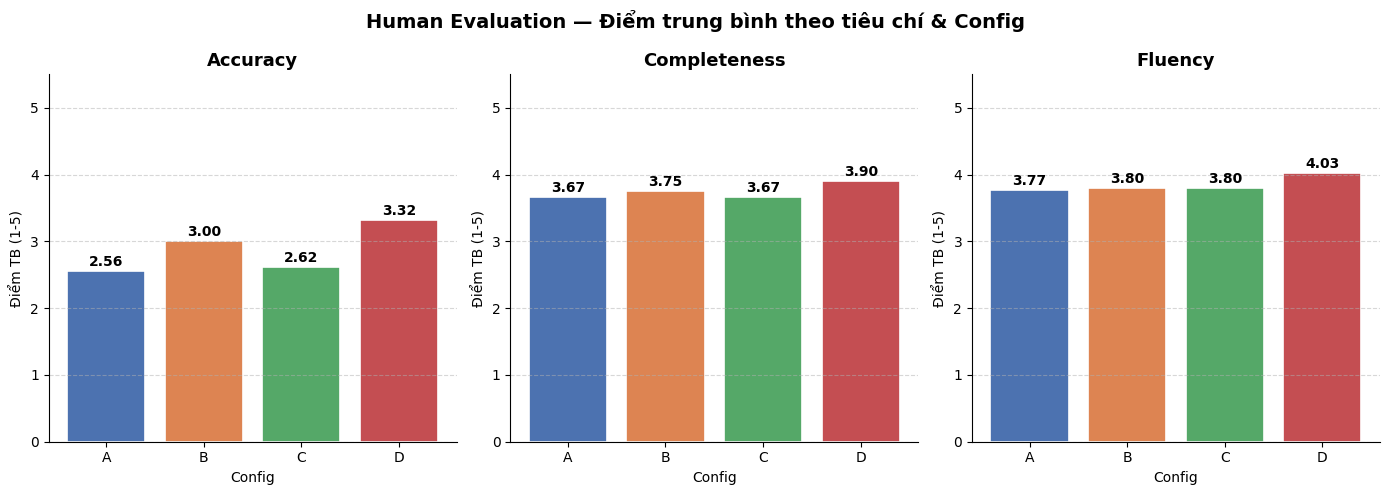

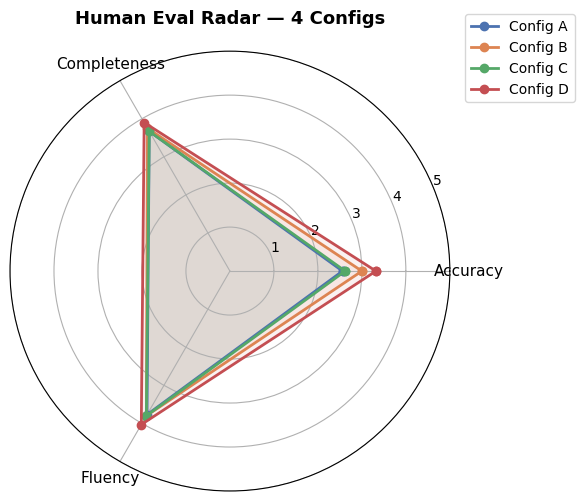

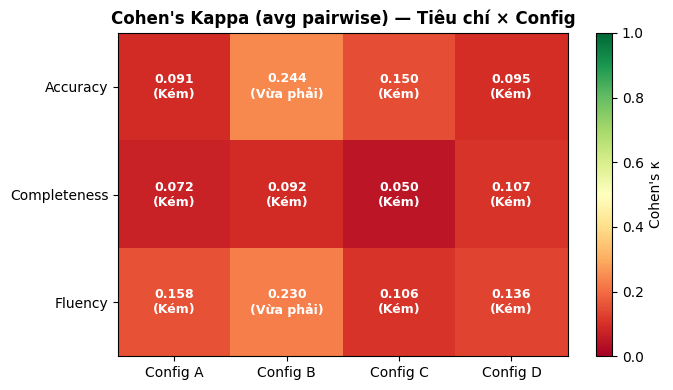

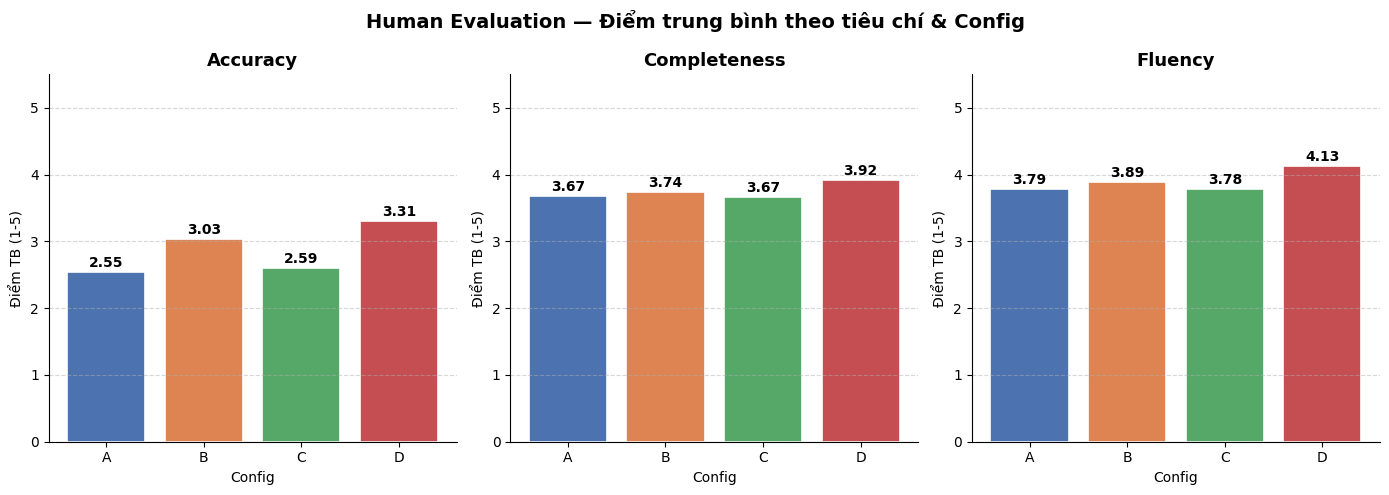

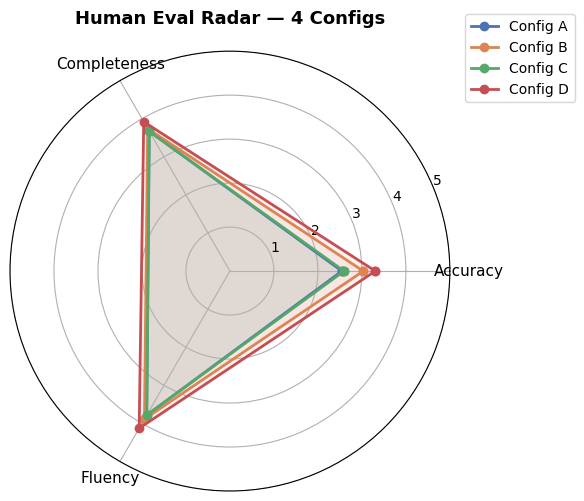

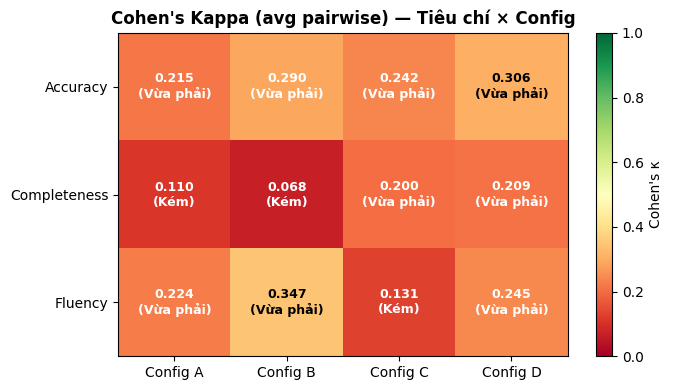


Đã lưu kết quả:
 ./results/human_eval_summary.csv — bảng tổng hợp
 ./results/human_eval_kappa_detail.csv — kappa từng cặp
 ./results/human_eval_mean_scores.csv — điểm TB từng câu
 ./results/human_eval_bars.png
 ./results/human_eval_radar.png
 ./results/human_eval_kappa_heatmap.png


In [ ]:
# CẤU HÌNH
ANNOTATOR_DIR  = "./results"# Thư mục chứa các file CSV của annotators
ANNOTATOR_FILES = None # None = tự động tìm tất cả *.csv trong ANNOTATOR_DIR
CSV_SEP = ";" # Dấu phân cách trong file CSV (';' hoặc ',')
# Các cột điểm cần phân tích
SCORE_COLS = [
  "accuracy_A", "accuracy_B", "accuracy_C", "accuracy_D",
  "completeness_A", "completeness_B", "completeness_C", "completeness_D",
  "fluency_A", "fluency_B", "fluency_C", "fluency_D",
]
CONFIGS = ["A", "B", "C", "D"]
CRITERIA = ["accuracy", "completeness", "fluency"]
OUTPUT_DIR = "./results"

# Load các file CSV
if ANNOTATOR_FILES:
  csv_files = ANNOTATOR_FILES
else:
  csv_files = sorted(glob.glob(os.path.join(ANNOTATOR_DIR, "*.csv")))
  # Loại bỏ file template và summary để tránh đọc nhầm
  csv_files = [f for f in csv_files if not any(
    kw in os.path.basename(f).lower()
      for kw in ["template", "summary", "final", "_ckpt"]
  )]

if len(csv_files) < 2:
  raise ValueError(
    f"Cần ít nhất 2 file CSV annotator, hiện chỉ tìm thấy {len(csv_files)}.\n"
    f"Các file tìm thấy: {csv_files}\n"
    "Hãy kiểm tra ANNOTATOR_DIR hoặc chỉ định ANNOTATOR_FILES."
  )

annotator_names = [os.path.splitext(os.path.basename(f))[0] for f in csv_files]
print(f"Tìm thấy {len(csv_files)} annotators:")
for name, path in zip(annotator_names, csv_files):
  print(f"  {name}: {path}")

dfs = {}
for name, path in zip(annotator_names, csv_files):
  df = pd.read_csv(path, sep=CSV_SEP)
  # Chuẩn hoá: chỉ giữ các cột điểm, convert sang số
  for col in SCORE_COLS:
      if col in df.columns:
          df[col] = pd.to_numeric(df[col], errors="coerce")
  dfs[name] = df
  print(f"   {name}: {len(df)} câu, {df[SCORE_COLS].notna().all(axis=1).sum()} câu đã chấm đủ")

# Chỉ giữ những hàng mà TẤT CẢ annotators đều đã chấm đủ
valid_mask = pd.concat(
    [dfs[n][SCORE_COLS].notna().all(axis=1) for n in annotator_names], axis=1
).all(axis=1)
n_valid = valid_mask.sum()
print(f"\nSố câu hợp lệ (tất cả annotators đã chấm): {n_valid}")


# Cohen's Kappa (pairwise)
def compute_pairwise_kappa(dfs, annotator_names, score_cols, valid_mask):
  pairs = list(itertools.combinations(annotator_names, 2))
  results = {}
  for col in score_cols:
    row = {}
    for ann1, ann2 in pairs:
      y1 = dfs[ann1].loc[valid_mask, col].dropna().astype(int)
      y2 = dfs[ann2].loc[valid_mask, col].dropna().astype(int)
      # Đảm bảo cùng index
      idx = y1.index.intersection(y2.index)
      try:
        kappa = cohen_kappa_score(y1.loc[idx], y2.loc[idx])
      except Exception:
        kappa = float("nan")
      row[f"{ann1} vs {ann2}"] = round(kappa, 4)
    results[col] = row
  return pd.DataFrame(results).T


def avg_kappa_per_criterion_config(kappa_df, criteria, configs):
  records = []
  pair_cols = kappa_df.columns.tolist()
  for crit in criteria:
    for cfg in configs:
      col = f"{crit}_{cfg}"
      if col in kappa_df.index:
        avg_k = kappa_df.loc[col, pair_cols].mean()
        records.append({"Criterion": crit, "Config": cfg, "Avg Cohen's Kappa": round(avg_k, 4)})
  return pd.DataFrame(records)


def interpret_kappa(k):
  if pd.isna(k): return "N/A"
  if k < 0.20: return "Kém"
  if k < 0.40: return "Vừa phải"
  if k < 0.60: return "Trung bình"
  if k < 0.80: return "Tốt"
  return "Rất tốt"


print("\nTính Cohen's Kappa...")
kappa_df = compute_pairwise_kappa(dfs, annotator_names, SCORE_COLS, valid_mask)
kappa_summary = avg_kappa_per_criterion_config(kappa_df, CRITERIA, CONFIGS)
kappa_summary["Interpretation"] = kappa_summary["Avg Cohen's Kappa"].apply(interpret_kappa)

print("\nCOHEN'S KAPPA — Trung bình theo tiêu chí & config:")
display(kappa_summary.pivot(index="Criterion", columns="Config", values="Avg Cohen's Kappa"))


# Điểm trung bình (mean score) qua các annotators
mean_scores = {}
for col in SCORE_COLS:
  scores = np.array([dfs[n].loc[valid_mask, col].values for n in annotator_names], dtype=float)
  mean_scores[col] = np.nanmean(scores, axis=0)

df_mean = dfs[annotator_names[0]].loc[valid_mask, ["question", "reference"] +
           [c for c in ["pred_A","pred_B","pred_C","pred_D"] if c in dfs[annotator_names[0]].columns]].copy()
for col, vals in mean_scores.items():
  df_mean[f"mean_{col}"] = np.round(vals, 3)


# Bảng tổng hợp theo config
summary_rows = []
for cfg in CONFIGS:
  row = {"Config": cfg}
  for crit in CRITERIA:
    col = f"{crit}_{cfg}"
    row[crit.capitalize()] = round(df_mean[f"mean_{col}"].mean(), 4)
  row["Overall"] = round(np.mean([row[c.capitalize()] for c in CRITERIA]), 4)
  # Avg kappa cho config này
  cfg_kappas = kappa_summary[kappa_summary["Config"] == cfg]["Avg Cohen's Kappa"]
  row["Avg Kappa"] = round(cfg_kappas.mean(), 4)
  row["Kappa Interp."] = interpret_kappa(row["Avg Kappa"])
  summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
print("\nBẢNG TỔNG HỢP HUMAN EVAL:")
display(df_summary)


# Chi tiết kappa từng cặp annotators
print("\nCOHEN'S KAPPA — Chi tiết từng cặp annotators:")
display(kappa_df.style.format("{:.4f}").background_gradient(cmap="RdYlGn", vmin=0, vmax=1))


# Biểu đồ
os.makedirs(OUTPUT_DIR, exist_ok=True)
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# Bar chart: điểm trung bình theo tiêu chí & config
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for ax, crit in zip(axes, CRITERIA):
  vals = [df_summary.loc[df_summary["Config"] == cfg, crit.capitalize()].values[0] for cfg in CONFIGS]
  bars = ax.bar(CONFIGS, vals, color=colors, edgecolor="white", linewidth=1.2)
  for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, f"{v:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
  ax.set_title(crit.capitalize(), fontsize=13, fontweight="bold")
  ax.set_ylim(0, 5.5)
  ax.set_ylabel("Điểm TB (1-5)")
  ax.set_xlabel("Config")
  ax.grid(axis="y", linestyle="--", alpha=0.5)
  ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Human Evaluation — Điểm trung bình theo tiêu chí & Config", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/human_eval_bars.png", dpi=150, bbox_inches="tight")
plt.show()

# adar chart: tổng hợp 4 configs
labels = [c.capitalize() for c in CRITERIA]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
for i, cfg in enumerate(CONFIGS):
  vals = [df_summary.loc[df_summary["Config"] == cfg, c.capitalize()].values[0] for c in CRITERIA]
  vals += vals[:1]
  ax.plot(angles, vals, "o-", linewidth=2, label=f"Config {cfg}", color=colors[i])
  ax.fill(angles, vals, alpha=0.08, color=colors[i])
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
ax.set_ylim(0, 5)
ax.set_title("Human Eval Radar — 4 Configs", pad=20, fontsize=13, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/human_eval_radar.png", dpi=150, bbox_inches="tight")
plt.show()

# Heatmap Cohen's Kappa: criterion x config (avg across pairs)
kappa_pivot = kappa_summary.pivot(index="Criterion", columns="Config", values="Avg Cohen's Kappa")
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(kappa_pivot.values.astype(float), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(CONFIGS))); ax.set_xticklabels([f"Config {c}" for c in CONFIGS])
ax.set_yticks(range(len(CRITERIA))); ax.set_yticklabels([c.capitalize() for c in CRITERIA])
for i in range(len(CRITERIA)):
  for j in range(len(CONFIGS)):
    val = kappa_pivot.values[i, j]
    ax.text(j, i, f"{val:.3f}\n({interpret_kappa(val)})",
      ha="center", va="center", fontsize=9, fontweight="bold",
      color="black" if 0.3 < val < 0.8 else "white")
plt.colorbar(im, ax=ax, label="Cohen's κ")
ax.set_title("Cohen's Kappa (avg pairwise) — Tiêu chí × Config", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/human_eval_kappa_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)



# Lưu kết quả
df_summary.to_csv(f"{OUTPUT_DIR}/human_eval_summary.csv", index=False, encoding="utf-8-sig")
kappa_df.to_csv(f"{OUTPUT_DIR}/human_eval_kappa_detail.csv", encoding="utf-8-sig")
df_mean.to_csv(f"{OUTPUT_DIR}/human_eval_mean_scores.csv", index=False, encoding="utf-8-sig")

print("\nĐã lưu kết quả:")
print(f" {OUTPUT_DIR}/human_eval_summary.csv — bảng tổng hợp")
print(f" {OUTPUT_DIR}/human_eval_kappa_detail.csv — kappa từng cặp")
print(f" {OUTPUT_DIR}/human_eval_mean_scores.csv — điểm TB từng câu")
print(f" {OUTPUT_DIR}/human_eval_bars.png")
print(f" {OUTPUT_DIR}/human_eval_radar.png")
print(f" {OUTPUT_DIR}/human_eval_kappa_heatmap.png")

## 15. Web Demo — Gradio (4 Config so sánh song song)

In [17]:
!pip install -q gradio
import gradio as gr
# Copy file web_demo.py vào Colab

gr.close_all()
exec(open("web_demo.py").read())

<string>:267: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
<string>:308: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
<string>:308: DeprecationWarning: The 'bubble_full_width' parameter will be removed in Gradio 6.0. This parameter no longer has any effect.
<string>:308: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.


* Running on public URL: https://8c63d79d9fcf2671f8.gradio.live
